Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


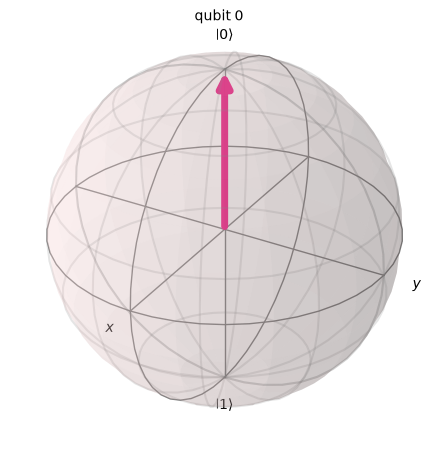

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

qc = QuantumCircuit(1)
state = Statevector.from_instruction(qc)

print(state)

state.draw("bloch")

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


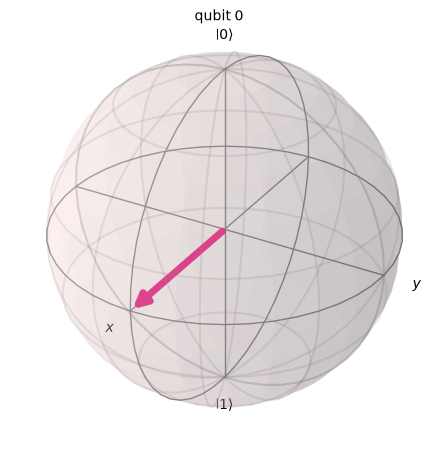

In [7]:
qc.ry(np.pi/2, 0)

state = Statevector.from_instruction(qc)

print(state)

state.draw("bloch")

結果：

赤道へ移動

Statevector([0.70710678-0.70710678j, 0.        +0.j        ],
            dims=(2,))


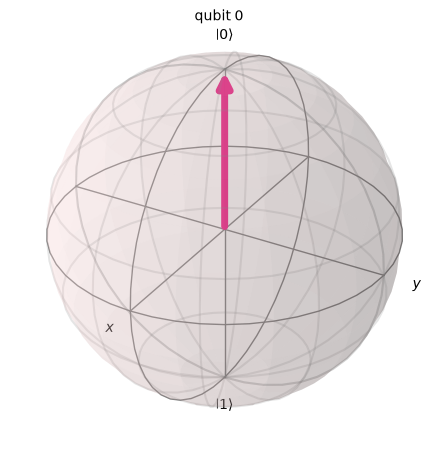

In [8]:
qc = QuantumCircuit(1)
qc.rz(np.pi/2, 0)

state = Statevector.from_instruction(qc)

print(state)

state.draw("bloch")

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


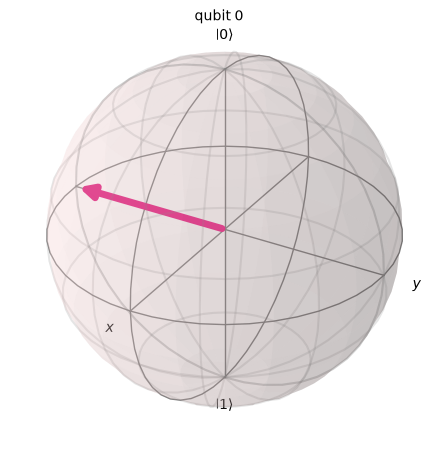

In [10]:
qc = QuantumCircuit(1)
qc.rx(np.pi/2, 0)

state = Statevector.from_instruction(qc)

print(state)

state.draw("bloch")

## 14. 回転ゲートと位相の関係

重要：

```text
Rz = 位相回転
```

つまり：

| ゲート | 等価      |
| --- | ------- |
| Z   | Rz(π)   |
| S   | Rz(π/2) |
| T   | Rz(π/4) |

資格試験頻出です。

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


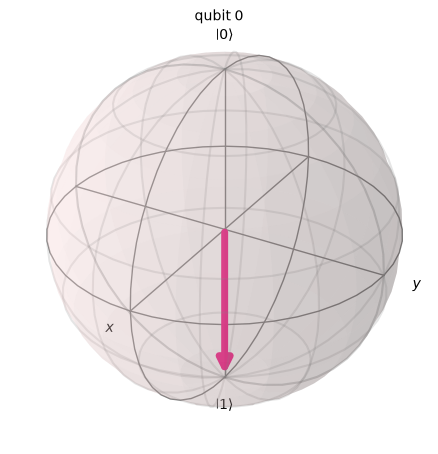

In [16]:
qc = QuantumCircuit(1)
qc.x(0)
state = Statevector.from_instruction(qc)

print(state)
state.draw("bloch")

Statevector([ 0.+0.j, -1.+0.j],
            dims=(2,))


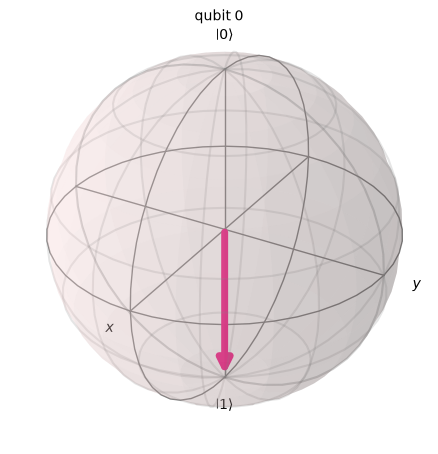

In [19]:
qc = QuantumCircuit(1)
qc.x(0)
qc.z(0)

state = Statevector.from_instruction(qc)

print(state)
state.draw("bloch")

Zゲートは「0を変えず、1の成分の符号（位相）だけ反転する」ゲート

Statevector([0.000000e+00+0.j, 6.123234e-17+1.j],
            dims=(2,))


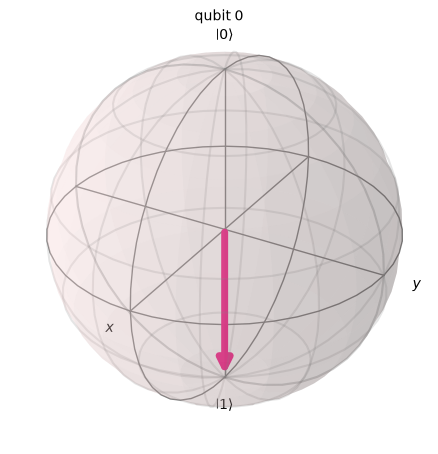

In [20]:
qc = QuantumCircuit(1)
qc.x(0)
qc.rz(np.pi, 0)

state = Statevector.from_instruction(qc)

print(state)
state.draw("bloch")

ブロッホ球の矢印が変わらないのはなぜか？

これは **$|1\rangle$ と $-|1\rangle$ が Bloch 球上では同じ点を表す**からです。

最初の回路では、

```python
qc = QuantumCircuit(1)
qc.x(0)
```

なので、

$$
|0\rangle \xrightarrow{X} |1\rangle
$$

です。

Statevector は

$$
\begin{pmatrix}
0\\
1
\end{pmatrix}
$$

ですね。

一方、2つ目では

```python
qc.x(0)
qc.z(0)
```

なので、

$$
|0\rangle
\xrightarrow{X}
|1\rangle
\xrightarrow{Z}
-|1\rangle
$$

です。

Statevector は実際に画像でも、

$$
\begin{pmatrix}
0\\
-1
\end{pmatrix}
$$

になっています。

ただし、

$$
|1\rangle
\quad\text{と}\quad
-|1\rangle
$$

の違いは **全体位相（global phase）** だけです。

一般に、

$$
|\psi\rangle
\quad\text{と}\quad
e^{i\phi}|\psi\rangle
$$

は、同じ物理的な量子状態を表します。

今回なら

$$
-|1\rangle
=
e^{i\pi}|1\rangle
$$

です。

Bloch 球が表しているのは、こうした全体位相を区別しない「物理的な状態」なので、どちらも同じ南極を指します。

つまり、画像の2つはこういう関係です。

$$
\begin{array}{c|c|c}
\text{回路} & \text{Statevector} & \text{Bloch球}\\
\hline
X & |1\rangle & \text{南極}\\
XZ & -|1\rangle & \text{南極}
\end{array}
$$

ここはかなり大事です。**Statevector は全体位相の違いまで表示するが、Bloch 球ではその違いは消える**、ということです。

逆に、Zゲートで Bloch 球上の矢印が変わる例としては、

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

に Z をかける場合があります。

$$
Z|+\rangle
=
|-\rangle
$$

なので、

$$
+x \longrightarrow -x
$$

と Bloch 球上で矢印が反対側へ移動します。

この違いを見ると、「Z はいつ効いて、いつ見かけ上効かないのか」がかなりクリアになります。


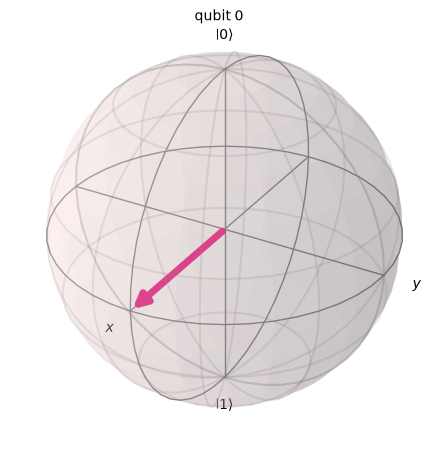

In [23]:
qc = QuantumCircuit(1)

qc.h(0)      # |0> -> |+>

state = Statevector.from_instruction(qc)
state.draw("bloch")

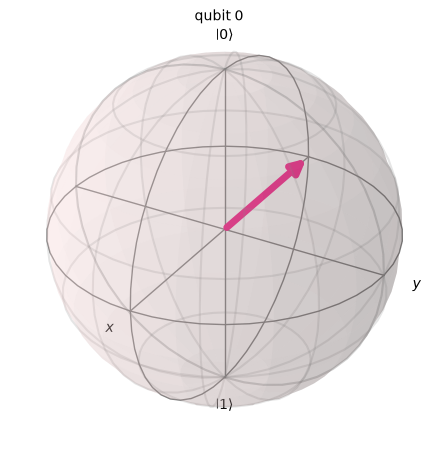

In [21]:
qc = QuantumCircuit(1)

qc.h(0)   # |0> -> |+>
qc.z(0)

state = Statevector.from_instruction(qc)
state.draw("bloch")

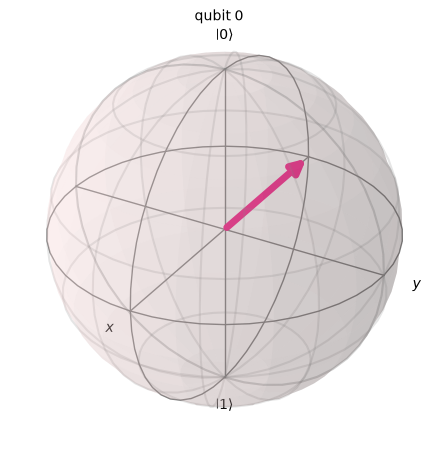

In [22]:
qc = QuantumCircuit(1)

qc.h(0)      # |0> -> |+>
qc.rz(np.pi, 0)

state = Statevector.from_instruction(qc)
state.draw("bloch")

はい。**S と T を Bloch 球上の変化として確認するなら、$|+\rangle$ から始めるのがいちばん分かりやすい**です。

理由は単純で、$S$ や $T$ は Z 軸まわりの回転なので、Z 軸上の $|0\rangle, |1\rangle$ から始めると、Bloch 球上では矢印が動きません。逆に、赤道上の状態から始めると回転がそのまま見えます。

おすすめはこれです。

| ゲート                 | 初期状態 | Bloch球上の変化 |                     |
| ------------------- | ---- | ---------- | ------------------- |
| $S = R_z(\pi/2)$ 相当 | $    | +\rangle$  | $+x \to +y$         |
| $T = R_z(\pi/4)$ 相当 | $    | +\rangle$  | $+x$ から $+y$ 方向へ45° |

$|+\rangle$ は

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

なので、Bloch 球の $+x$ 方向です。

### S の確認

```python
qc = QuantumCircuit(1)
qc.h(0)      # |0> -> |+>
qc.s(0)

state = Statevector.from_instruction(qc)
state.draw("bloch")
```

これは $+x$ から $+y$ へ90°回転して見えます。

比較して、

```python
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(np.pi/2, 0)
```

としても、Bloch球では同じ位置になります。

### T の確認

```python
qc = QuantumCircuit(1)
qc.h(0)      # |0> -> |+>
qc.t(0)

state = Statevector.from_instruction(qc)
state.draw("bloch")
```

すると、$+x$ から $+y$ の中間、つまり45°の位置になります。

比較対象は、

```python
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(np.pi/4, 0)
```

です。

ただし、Z の場合と同じで、厳密には

$$
S \neq R_z(\pi/2)
$$

$$
T \neq R_z(\pi/4)
$$

で、**全体位相だけ違います**。

実際には、

$$
S = e^{i\pi/4} R_z(\pi/2)
$$

$$
T = e^{i\pi/8} R_z(\pi/4)
$$

です。

なので、確認としては

> Statevector の数値は違うことがある
> でも Bloch 球では同じ点になる

というのを見るのがちょうどよいです。

今回の流れなら、**Z, S, T を全部 $|+\rangle$ から始めて並べる**とかなり教育的です。

$$
|+\rangle
\overset{T}{\longrightarrow}45^\circ
\overset{T}{\longrightarrow}90^\circ
\overset{S}{\longrightarrow}180^\circ
$$

あるいは直接、

$$
R_z(\pi/4),\quad R_z(\pi/2),\quad R_z(\pi)
$$

を並べて、Bloch球で「Z軸まわりに45°、90°、180°」と見ると、T・S・Z の関係が一気につながります。


はい。**「等価」とだけ書くと、少し雑です。**
数学的には $Z,S,T$ と対応する $R_z$ は、**全体位相を除いて同じ**です。

正確には、

$$
Z = e^{i\pi/2} R_z(\pi)
$$

$$
S = e^{i\pi/4} R_z(\pi/2)
$$

$$
T = e^{i\pi/8} R_z(\pi/4)
$$

です。

なので、添付の表の

| ゲート | 等価           |
| --- | ------------ |
| Z   | $R_z(\pi)$   |
| S   | $R_z(\pi/2)$ |
| T   | $R_z(\pi/4)$ |

は、**「物理的な作用として等価」「global phase を無視すれば等価」**という意味ならOKです。
一方で、**行列として完全に等しい**という意味では正しくありません。

試験対策のメモとしては、たとえばこう直すのが安全です。

> $Z,S,T$ はそれぞれ、global phase を除けば $R_z(\pi), R_z(\pi/2), R_z(\pi/4)$ と同じ作用をする。

あるいは表を

| ゲート | global phase を除けば |
| --- | ----------------- |
| Z   | $R_z(\pi)$        |
| S   | $R_z(\pi/2)$      |
| T   | $R_z(\pi/4)$      |

としておくと、かなり正確です。

今回 Bloch 球で同じ位置になったのは、まさに **Bloch 球が global phase を区別しない**からです。
